# 07 — Figure 2 replica

Reproduces Oliver et al. (2018) **Fig. 2**, "Total number of marine heatwave
days globally", from ESA SST CCI v3.0 + XMHW instead of NOAA OI SST.

The layout deliberately matches the original — same axes, same colours, same
shading scheme — so the two can be laid side by side and judged by eye. A
reader cannot evaluate "31.77 versus 30" at a glance, but they can evaluate
two curves.

**Colours are sampled from the paper's own figure** at 200 dpi
(`pdftoppm -r 200`), not eyeballed:

| element | colour |
|---|---|
| global average line | `#000000` |
| excluding-ENSO line | `#ed3c3c` |
| El Niño shading | `#f3b9b9` |
| La Niña shading | `#b3b3f3` |

Verified colour-vision safe (`pixi run check-colors`): worst separation
ΔE 36.9 under deuteranopia, protanopia or tritanopia, against a threshold of
20. The palette is safe because it opposes blue and red rather than red and
green, so it is reused unchanged.

Matching the design must not extend to matching the *identity*: a figure
outlives its caption, so a provenance line naming the dataset and software is
stamped on the face. It should never be mistakable for the original.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

TARGET_RES_DEG = float(os.environ.get("MHW_TARGET_RES_DEG", 1.0))
RESULTS_DIR = Path("../results")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Sampled from the paper — see the table above.
C_BLACK = "#000000"
C_RED = "#ed3c3c"
C_ELNINO = "#f3b9b9"
C_LANINA = "#b3b3f3"

MEI_THRESHOLD = 1.0   # "exceeding +/-1 s.d. of the MEI index"
MEI_RUN_MONTHS = 3    # "...for three consecutive months"

In [2]:
black = xr.open_dataset(RESULTS_DIR / f"mhw_annual_{TARGET_RES_DEG:g}deg.nc")
red = xr.open_dataset(
    RESULTS_DIR / f"mhw_annual_{TARGET_RES_DEG:g}deg_enso_removed.nc")
cmp_all = json.load(open(RESULTS_DIR / "headline_comparison.json"))

years = black["year"].values
days_all = black["global_mhw_days"].values
days_noenso = red["global_mhw_days"].values
print(f"black line: {days_all.min():.1f}..{days_all.max():.1f} days")
print(f"red line  : {days_noenso.min():.1f}..{days_noenso.max():.1f} days")

black line: 12.5..94.1 days
red line  : 11.9..70.4 days


## El Niño and La Niña periods

The caption defines them as periods where the MEI exceeds ±1 s.d. for three
consecutive months. The MEI is published in units of standard deviations, so
the test is directly on its value.

In [3]:
mei = pd.read_csv("../data/raw/mei_original.csv", index_col=0,
                  parse_dates=True)["mei"]
mei = mei[(mei.index.year >= years[0] - 1) & (mei.index.year <= years[-1] + 1)]


def sustained_periods(series: pd.Series, sign: int) -> list[tuple]:
    """Spans where sign*MEI exceeds the threshold for >= MEI_RUN_MONTHS months."""
    hit = (series * sign) > MEI_THRESHOLD
    spans, start, run = [], None, 0
    for stamp, is_hit in hit.items():
        if is_hit:
            start = stamp if run == 0 else start
            run += 1
        else:
            if run >= MEI_RUN_MONTHS:
                spans.append((start, prev))
            start, run = None, 0
        prev = stamp
    if run >= MEI_RUN_MONTHS:
        spans.append((start, prev))
    return spans


el_nino = sustained_periods(mei, +1)
la_nina = sustained_periods(mei, -1)
print(f"{len(el_nino)} El Nino and {len(la_nina)} La Nina periods "
      f"({years[0]}-{years[-1]})")


def to_year(stamp) -> float:
    """Decimal year, so shading aligns with the annual x-axis."""
    return stamp.year + (stamp.dayofyear - 1) / 365.25

10 El Nino and 4 La Nina periods (1982-2016)


## The figure

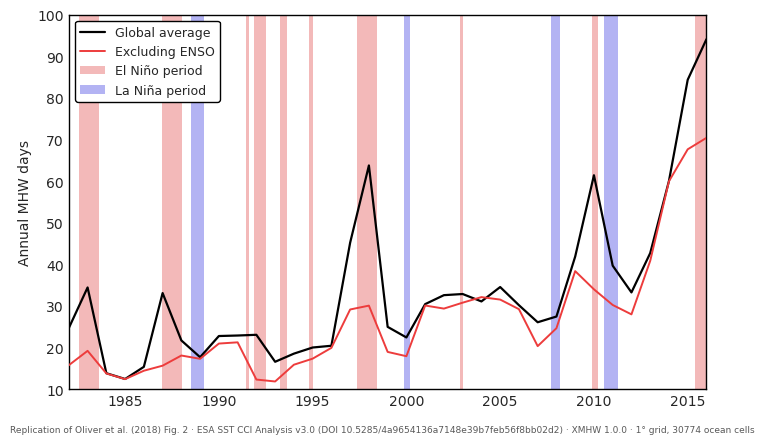

In [4]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7.2, 4.4))

# Shading first, so the lines sit on top of it.
for spans, colour, label in ((el_nino, C_ELNINO, "El Niño period"),
                             (la_nina, C_LANINA, "La Niña period")):
    for i, (t0, t1) in enumerate(spans):
        ax.axvspan(to_year(t0), to_year(t1), color=colour, lw=0, zorder=1,
                   label=label if i == 0 else None)

ax.plot(years, days_all, color=C_BLACK, lw=1.6, zorder=3, label="Global average")
ax.plot(years, days_noenso, color=C_RED, lw=1.4, zorder=3, label="Excluding ENSO")

ax.set_ylabel("Annual MHW days")
ax.set_xlim(years[0], years[-1])
ax.set_ylim(10, 100)
ax.set_yticks(range(10, 101, 10))
ax.set_xticks([1985, 1990, 1995, 2000, 2005, 2010, 2015])
ax.grid(False)
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")

# Legend order follows the paper: two lines, then the two shadings.
handles, labels = ax.get_legend_handles_labels()
order = [labels.index(k) for k in
         ("Global average", "Excluding ENSO", "El Niño period", "La Niña period")
         if k in labels]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          loc="upper left", frameon=True, framealpha=1.0, edgecolor="black",
          fontsize=9)

prov = cmp_all["replication"]
fig.text(
    0.01, 0.005,
    f"Replication of Oliver et al. (2018) Fig. 2 · ESA SST CCI Analysis v3.0 "
    f"(DOI {prov['dataset_doi']}) · XMHW {prov.get('software_version', '?')} · "
    f"{prov['resolution_deg']:g}° grid, {prov['n_cells']} ocean cells",
    fontsize=6.5, color="0.35",
)

fig.tight_layout(rect=[0, 0.025, 1, 1])
fig.savefig(FIG_DIR / "figure2_replica.png", dpi=200, bbox_inches="tight")
fig.savefig(FIG_DIR / "figure2_replica.pdf", bbox_inches="tight")
plt.show()

In [5]:
print(f"red below black in {(days_noenso < days_all).sum()}/{len(years)} years; "
      f"mean reduction {np.mean(days_all - days_noenso):.2f} days/yr")

red below black in 34/35 years; mean reduction 6.76 days/yr
